In [1]:
# 0) Imports y configuración
import sys
import subprocess

# Instalar ucimlrepo si no está (para asemejar el flujo del ejemplo de clase)
try:
    import ucimlrepo  # noqa: F401
except Exception:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo", "-q"])
    except Exception as e:
        print("No se pudo instalar ucimlrepo:", e)

# Imports científicos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA

# Estilo general
pd.set_option('display.precision', 4)
plt.rcParams['figure.figsize'] = (7, 4)
sns.set(style="whitegrid")

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
# 1) Carga del dataset desde UCI (fallback seaborn)
def cargar_iris():
    """
    Intenta cargar Iris desde UCI usando ucimlrepo (id=53).
    Si falla, usa seaborn.load_dataset('iris').
    Devuelve df con columnas: sepal_length, sepal_width, petal_length, petal_width, species
    """
    cols = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
    # Intento vía ucimlrepo
    try:
        from ucimlrepo import fetch_ucirepo
        iris = fetch_ucimlrepo(id=53)  # Iris
        # Algunos mirrors devuelven en dos tablas: features (X) y targets (y)
        if hasattr(iris, "data"):
            X = iris.data.features.copy()
            y = iris.data.targets.copy()
            # Estandarizar nombres de columnas y asegurar 'species' como categórica/string
            X.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
            if y.shape[1] == 1:
                y.columns = ["species"]
            elif "class" in y.columns:
                y = y.rename(columns={"class": "species"})
            df = pd.concat([X, y], axis=1)
        else:
            # Fallback por si el objeto no tiene .data en esta versión
            raise RuntimeError("Estructura inesperada en ucimlrepo.fetch_ucirepo(id=53)")
        print("✅ Iris cargado desde UCI (ucimlrepo)")
        return df
    except Exception as e:
        print("Aviso: no se pudo cargar desde UCI por ucimlrepo ->", e)
        print("Usando seaborn.load_dataset('iris') como alternativa...")
        df = sns.load_dataset("iris")
        df = df.rename(columns={
            "sepal_length": "sepal_length",
            "sepal_width": "sepal_width",
            "petal_length": "petal_length",
            "petal_width": "petal_width",
            "species": "species"
        })
        print("✅ Iris cargado desde seaborn")
        return df

df = cargar_iris()

Aviso: no se pudo cargar desde UCI por ucimlrepo -> name 'fetch_ucimlrepo' is not defined
Usando seaborn.load_dataset('iris') como alternativa...
✅ Iris cargado desde seaborn


In [3]:
# 2) Definir X (features) y y (target), y unir a Xy como en el ejemplo
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
target_col = "species"

X = df[feature_cols].copy()
y = df[[target_col]].copy()

print("\n📌 Metadatos simples")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

print("\n🔎 Primeras filas de X (features):")
print(X.head())

print("\n🔎 Primeras filas de y (target):")
print(y.head())

# Unir X y y en un único DataFrame (Xy)
Xy = pd.concat([X, y], axis=1)


📌 Metadatos simples
Filas: 150 | Columnas: 5

🔎 Primeras filas de X (features):
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

🔎 Primeras filas de y (target):
  species
0  setosa
1  setosa
2  setosa
3  setosa
4  setosa


In [4]:
# 3) Inspección inicial
print("\nℹ️ info():")
print(Xy.info())

print("\n📈 describe() variables numéricas:")
print(Xy.describe())


ℹ️ info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

📈 describe() variables numéricas:
       sepal_length  sepal_width  petal_length  petal_width
count      150.0000     150.0000      150.0000     150.0000
mean         5.8433       3.0573        3.7580       1.1993
std          0.8281       0.4359        1.7653       0.7622
min          4.3000       2.0000        1.0000       0.1000
25%          5.1000       2.8000        1.6000       0.3000
50%          5.8000       3.0000        4.3500       1.3000
75%          6.4000       3.3000        5.1000       1.8000
max        

In [5]:
# 4) Valores nulos y duplicados; imputación simple si aplicara
print("\n❓ Valores nulos por columna:")
print(Xy.isnull().sum())

# Imputación (por si hubiese NA en alguna versión/mirror)
num_cols = Xy.select_dtypes(include=[np.number]).columns
cat_cols = Xy.select_dtypes(exclude=[np.number]).columns

if Xy[num_cols].isnull().sum().sum() > 0:
    Xy[num_cols] = Xy[num_cols].fillna(Xy[num_cols].mean())

for c in cat_cols:
    if Xy[c].isnull().any():
        Xy[c] = Xy[c].fillna(Xy[c].mode()[0])

print("\n🧮 Duplicados totales:", Xy.duplicated().sum())
Xy = Xy.drop_duplicates().reset_index(drop=True)


❓ Valores nulos por columna:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

🧮 Duplicados totales: 1



📊 Histogramas (10 bins)


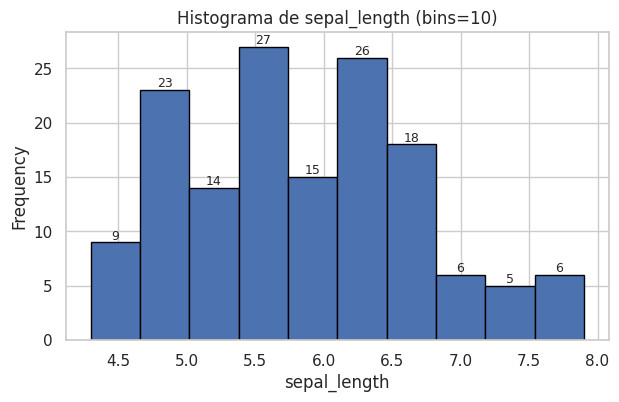

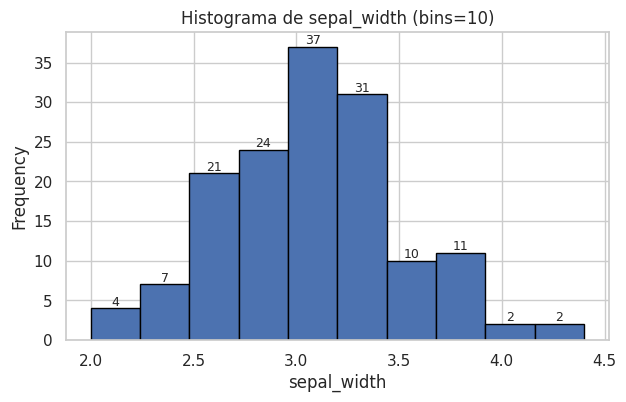

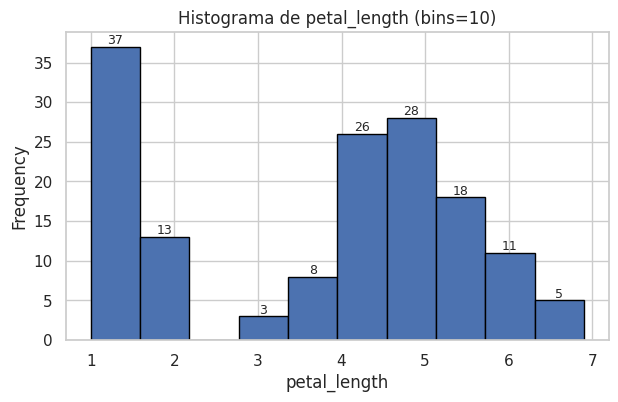

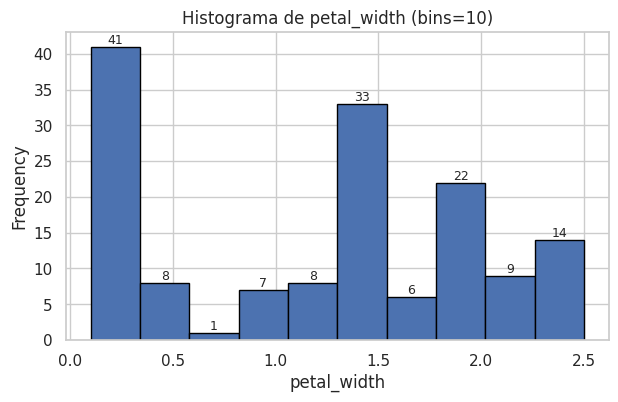

In [6]:
# 5) Histogramas (10 bins) con conteos
print("\n📊 Histogramas (10 bins)")
for col in feature_cols:
    ax = Xy[col].plot(kind='hist', bins=10, edgecolor='black', title=f"Histograma de {col} (bins=10)")
    ax.set_xlabel(col)
    # Anotar conteos sobre las barras
    for p in ax.patches:
        height = int(p.get_height())
        if height > 0:
            ax.annotate(height, (p.get_x() + p.get_width()/2, height),
                        ha='center', va='bottom', fontsize=9)
    plt.show()

¿Cómo es la distribución de la longitud del sépalo en comparación con la longitud del pétalo?
 1. Longitud del sépalo--> distribución normal centrada entre 5.0 y 6.0 cm. Se observan pocos outlayers con valores inferiores a 4.5 y mayores a 7.5. La mayoria de los sépalos son de tamaño medio sin grandes diferencias entre especies.
 2. Longitud del pétalo--> al contrario que la anterior esta variable no presenta una distribución normal sino bimodal o multimodal. En este caso podemos observar dos agrupaciones: pétalos pequeños (1-2 cm) que corresponde a Iris setosa; pétalos grandes (4-6cm) correspondiente a Versicolor y Virginica

¿Qué puedes inferir de estas distribuciones?
A la hora de clasificar las especies la longitud del pétalo es una variable más útil y eficiente. La distribución bimodal permite la separación clara de las especies. En cambio, la variabilidad homogénea presente en la longitud del sépalo no contribuye a emplear esta variable como rasgo diferenciador de las especies.


📦 Boxplots antes de limpiar outliers


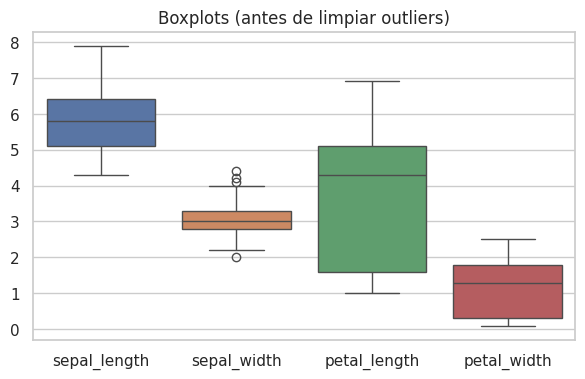

🔍 Filas con outliers detectadas: 4

Ejemplo de filas eliminadas por outliers:
    sepal_length  sepal_width  petal_length  petal_width     species
15           5.7          4.4           1.5          0.4      setosa
32           5.2          4.1           1.5          0.1      setosa
33           5.5          4.2           1.4          0.2      setosa
60           5.0          2.0           3.5          1.0  versicolor

📦 Boxplots después de limpiar outliers


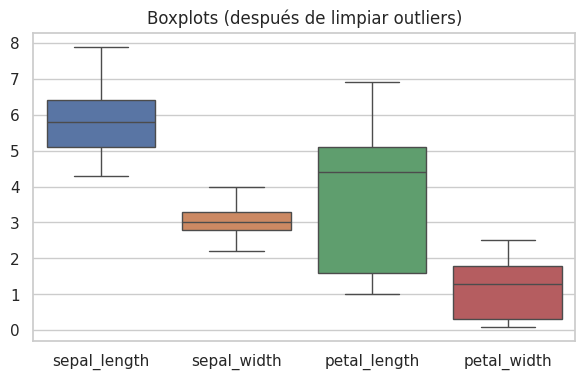


📑 Comparación de estadísticas (antes vs. después)
              count_before  mean_before  std_before  min_before  25%_before  \
sepal_length         149.0       5.8436      0.8309         4.3         5.1   
sepal_width          149.0       3.0597      0.4363         2.0         2.8   
petal_length         149.0       3.7490      1.7678         1.0         1.6   
petal_width          149.0       1.1946      0.7626         0.1         0.3   

              50%_before  75%_before  max_before  count_after  mean_after  \
sepal_length         5.8         6.4         7.9        145.0      5.8572   
sepal_width          3.0         3.3         4.4        145.0      3.0428   
petal_length         4.3         5.1         6.9        145.0      3.7979   
petal_width          1.3         1.8         2.5        145.0      1.2159   

              std_after  min_after  25%_after  50%_after  75%_after  max_after  
sepal_length     0.8370        4.3        5.1        5.8        6.4        7.9  
sepal

In [7]:
# 6) Boxplots y outliers (IQR=1.5)
print("\n📦 Boxplots antes de limpiar outliers")
sns.boxplot(data=Xy[feature_cols])
plt.title("Boxplots (antes de limpiar outliers)")
plt.show()

def iqr_outlier_mask(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return (s < lo) | (s > hi)

# Identificar filas con outliers en cualquiera de las columnas numéricas
outlier_flags = pd.DataFrame({c: iqr_outlier_mask(Xy[c]) for c in feature_cols})
any_outlier = outlier_flags.any(axis=1)
eliminados = Xy[any_outlier].copy()

print(f"🔍 Filas con outliers detectadas: {any_outlier.sum()}")
if not eliminados.empty:
    print("\nEjemplo de filas eliminadas por outliers:")
    print(eliminados.head())

# Crear dataset limpio
Xy_clean = Xy.loc[~any_outlier].reset_index(drop=True)

print("\n📦 Boxplots después de limpiar outliers")
sns.boxplot(data=Xy_clean[feature_cols])
plt.title("Boxplots (después de limpiar outliers)")
plt.show()

# Comparar estadísticas antes/después
before = Xy[feature_cols].describe().T
after = Xy_clean[feature_cols].describe().T
comparison = before.join(after, lsuffix="_before", rsuffix="_after")
print("\n📑 Comparación de estadísticas (antes vs. después)")
print(comparison)


📚 Estadísticas por especie (mean, median, min, max, std)
           sepal_length                          sepal_width                   \
                   mean median  min  max     std        mean median  min  max   
species                                                                         
setosa           4.9766    5.0  4.3  5.8  0.3389      3.3766    3.4  2.3  4.0   
versicolor       5.9551    5.9  4.9  7.0  0.5033      2.7857    2.8  2.2  3.4   
virginica        6.6041    6.5  4.9  7.9  0.6321      2.9796    3.0  2.2  3.8   

                   petal_length                          petal_width         \
               std         mean median  min  max     std        mean median   
species                                                                       
setosa      0.3272       1.4617    1.5  1.0  1.9  0.1788      0.2468    0.2   
versicolor  0.2965       4.2755    4.4  3.0  5.1  0.4617      1.3327    1.3   
virginica   0.3234       5.5612    5.6  4.5  6.9  0.5537    

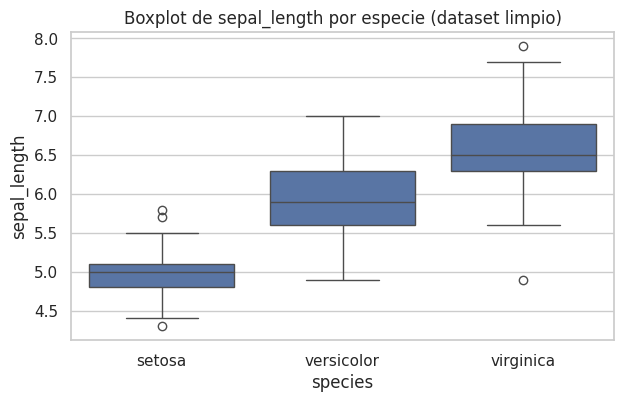

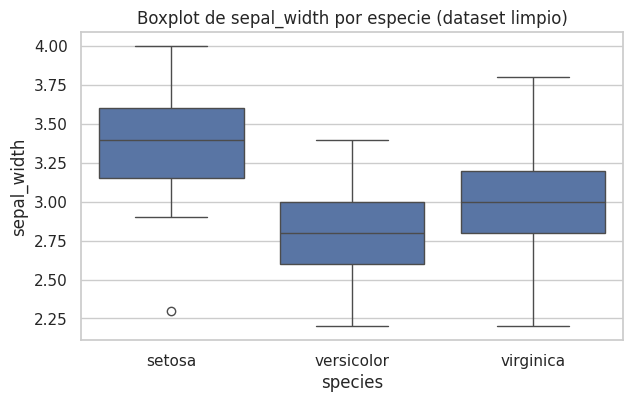

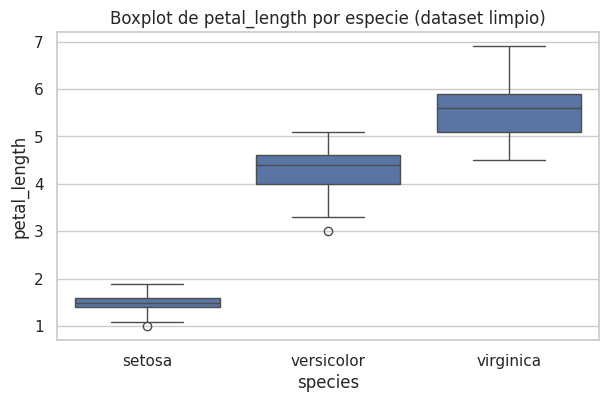

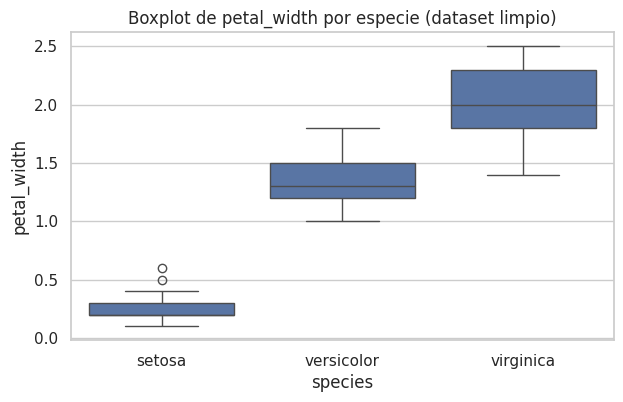

In [8]:
# 7) Estadísticas por especie
print("\n📚 Estadísticas por especie (mean, median, min, max, std)")
stats_by_species = (
    Xy_clean
    .groupby('species')[feature_cols]
    .agg(['mean', 'median', 'min', 'max', 'std'])
)
print(stats_by_species)

# Boxplots por especie
for col in feature_cols:
    sns.boxplot(data=Xy_clean, x='species', y=col)
    plt.title(f"Boxplot de {col} por especie (dataset limpio)")
    plt.show()

¿Cómo varían las distribuciones?
En ciertos aspectos se observa una separación clara por especie. Como es en el caso de las variables de pétalos (longitud y ancho) que discriminan fuertemente las especies. Se observa superposición moderada con rangos similares en algunas variables. Virginica repressenta la mayor variabilidad en general, reflejando mayor heterogeneidad morfológica.
Las medianas son muy próximas a las medias indicando que las distribuciones son aproximadamente simétricas y no presentan un sesgo fuerte de los valores.

¿Como varían las distribuciones de las características entre las especies?
1. Petal length
Variable con mayor variación entre especies. No se observa solapamiento de los valores entre las diferentes especies lo que indica que la variable es altamente discriminante.
- Setosa: distribución muy concentrada normal centrada en torno 1.5cm
-Versicolor: distribución normal centrada en trono a 4.5 cm
- Virginica: distribución asimétrica con valores entre 4.5-6.5

La variable no presenta una distribución normal entre las especies ya que se observan tres especies con medias muy distintas. Pero dentro de cada especie si que sigue una distribución normal o cuasinormal.


2. Petal width
Presenta diferencias claras entre las especies con poca superposición entre Vesicolor y Virginia
- Setosa: distribución asimétrica a la derecha,con valores bajos (0.1-0.5cm)
-Versicolor: distribución casi normal
- Virginica: distribución ligeramente asimétrica hacia la izquierda con valores entre 4.5-6.5cm.

Al igual que en el caso de "petal lenght" a nivel del dataset global la variable no sigue una distribucion normal. En cambio dentro de cada especie muestra una forma cercana a la normal.

3. Sepal lenght
Variación mas gradual con cierto solapamiento entre especies.
- Setosa: distribución aproximadamente normal, centrada alrededor de 5 cm, con poca dispersión.
- Versicolor: distribución ligeramente asimétrica a la izquierda (sesgo negativo), con valores concentrados entre 5.5 y 6.5 cm.
- Virginica: distribución ligeramente asimétrica a la derecha (sesgo positivo), más extendida (5.5–7.5 cm).

4. Sepal Width
Presenta la mayor superposición entre las especies.
- Setosa: distribución casi normal, con media en torno a 3.4 cm.
- Versicolor: distribución asimétrica negativa, más concentrada en valores bajos (~2.8 cm).
- Virginica: distribución asimétrica positiva, más dispersa, con una cola hacia valores altos (~3.0–3.8 cm).

Es la variable menos normal en conjunto (presenta mayor superposición y variabilidad entre especies).

¿Cuál parece ser la característica más uniforme entre las especies?
La carcateristica más uniforme es aquella con distribuciones más similares entre las especies que en este caso sería el ancho del sépalo (sepal width). Con respecto a esta variable no se observan una elevada variación entre especies. Además los boxplots muestran valores muy solapados y medianas cercanas.


📏 Normalización Z-Score con StandardScaler


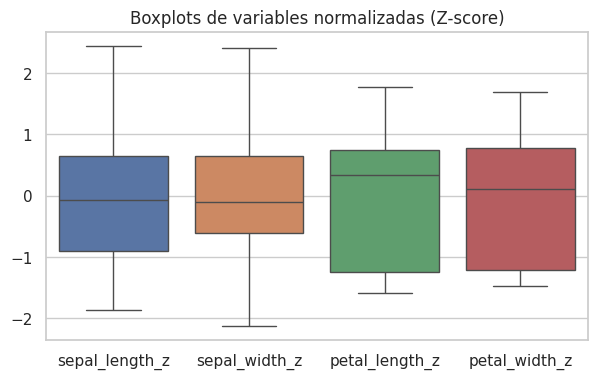

In [9]:
# 8) Normalización Z-Score
print("\n📏 Normalización Z-Score con StandardScaler")
scaler = StandardScaler()
scaled = scaler.fit_transform(Xy_clean[feature_cols])
Xy_scaled = Xy_clean.copy()
Xy_scaled[[c + "_z" for c in feature_cols]] = scaled

# Boxplots de normalizadas
sns.boxplot(data=Xy_scaled[[c + "_z" for c in feature_cols]])
plt.title("Boxplots de variables normalizadas (Z-score)")
plt.show()

¿Por qué es importante normalizar las variables antes de realizar algunos análisis?
Normalizar evita que variables con mayores magnitudes dominen sobre otras, estableciendo todos los valores dentro de una misma escala. Permite hacer las variables comparables de manera que se puedan interpretar distancias, correlaciones o pesos de manera coherente entre estas. A su vez mejora la convergencia y facilita la optimización de los datos.

¿Cómo cambia la visualización de los datos (por ejemplo, en un box plot) después
de normalizarlos?
Antes de la normalización cada variable tiene su propia escala y aquellas con valores más altos dominanel eje vertical. En cambio, tras la normalización todas las variables se expresan en unidades de desviación estandar, todas las variables tienen un tamaño común y las diferencias visuales en el boxplot reflejan la variabilidad relativa de las variables y no su tamaño físico.




🔗 Relación sepal_length vs petal_length por especie


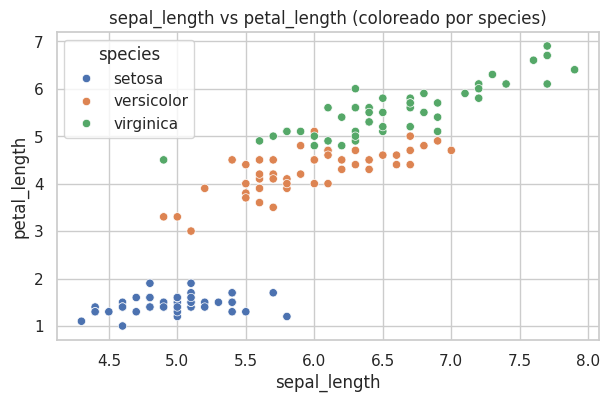

R² global: 0.7768 | pendiente=1.8542 | intercep=-7.0629
setosa     -> R²: 0.0819 | pendiente=0.1510 | intercep=0.7103
versicolor -> R²: 0.5452 | pendiente=0.6772 | intercep=0.2425
virginica  -> R²: 0.7447 | pendiente=0.7559 | intercep=0.5691


In [10]:
# 9) Scatter sepal_length vs petal_length + R² global y por especie
print("\n🔗 Relación sepal_length vs petal_length por especie")
sns.scatterplot(data=Xy_scaled, x='sepal_length', y='petal_length', hue='species')
plt.title("sepal_length vs petal_length (coloreado por species)")
plt.show()

def r2_between(df_, x, y):
    X_ = df_[[x]].values
    y_ = df_[y].values
    model = LinearRegression().fit(X_, y_)
    pred = model.predict(X_)
    return r2_score(y_, pred), model.coef_[0], model.intercept_

r2_g, b1, b0 = r2_between(Xy_scaled, 'sepal_length', 'petal_length')
print(f"R² global: {r2_g:.4f} | pendiente={b1:.4f} | intercep={b0:.4f}")
for sp in Xy_scaled['species'].unique():
    sub = Xy_scaled[Xy_scaled['species'] == sp]
    r2_sp, b1_sp, b0_sp = r2_between(sub, 'sepal_length', 'petal_length')
    print(f"{sp:10s} -> R²: {r2_sp:.4f} | pendiente={b1_sp:.4f} | intercep={b0_sp:.4f}")

¿Qué patrones observas entre las longitudes de sépalos y pétalos en las distintas
especies?
 ¿Alguna especie se distingue claramente de las demás?
 Se observa una relación positiva clara entre la longitud del sépalo y las del pétalo, ya que, al aumentar una variable se incrementa tambien la otra aunque la intensidad de esta relaicón varía según la especie.
- Iris setosa--> presenta valores localizados en la región inferior izquierda de la gráfica, de manera que se distingue claramente de las demás
- Iris vesicolor--> se situa en la región central mostrando una correlación positiva moderada entre ambas variables.
- Iris virginica--> ocupa la region superior derecha con valores incrementados y una correlación positiva fuerte.

Teniendo en cuenta lo anterior setosa se diferencia claramente de ambas especies, mientras que vesicolor y virginica presentan cierto solapamiento siguiendo patrones de crecimiento similares.

Indica que correlación tienen mediante el cálculo de r2 para cada uno de los
modelos.
- Setosa--> R^2= 0.0819 presenta una relación débil, los pétalos cambian poco al variar el sépalo
- Versicolor--> R^2= 0.5452 este caso se trata de una relación lineal moderada entre ambas variables.
- Virginica--> R^2= 0.7559 se trata de una relación fuerte y clara en la que la longitud de tanto los petalos como los sépalos está estrechamente asociada.


🧪 Correlación de Pearson


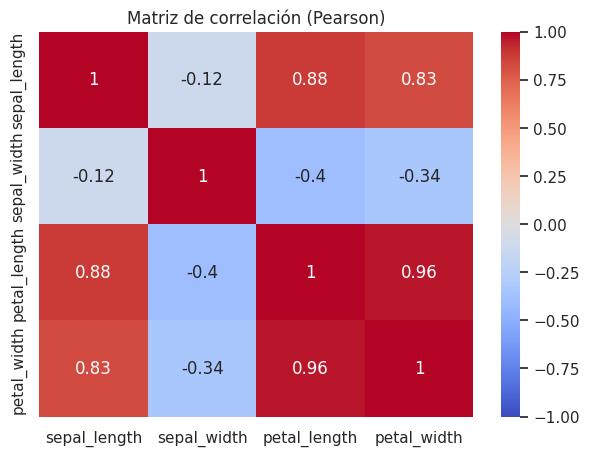


🧪 Correlación de Spearman


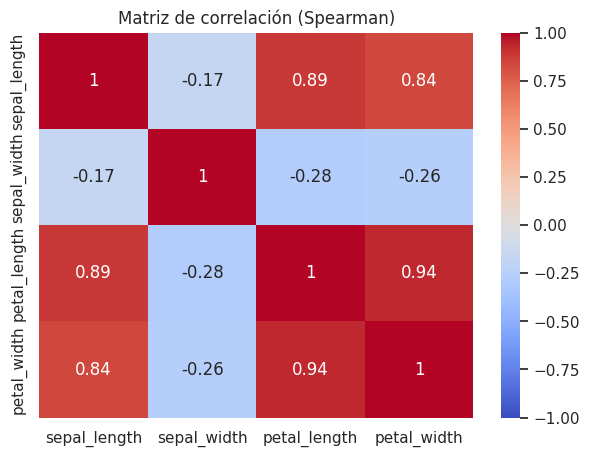

In [11]:
# 10) Correlaciones (Pearson y Spearman) y heatmaps
print("\n🧪 Correlación de Pearson")
corr_p = Xy_scaled[feature_cols].corr(method="pearson")
plt.figure(figsize=(7, 5))
sns.heatmap(corr_p, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación (Pearson)")
plt.show()

print("\n🧪 Correlación de Spearman")
corr_s = Xy_scaled[feature_cols].corr(method="spearman")
plt.figure(figsize=(7, 5))
sns.heatmap(corr_s, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación (Spearman)")
plt.show()

¿Qué variables tienen mayor correlación entre sí?
Petal_lenght y Petal_width presentan la mayor correlación positiva con un valor de 0.96 segun Pearson y un 0.94 según Spearman.

¿Qué significa esto en términos de las características de la flor?
Las flores con pétalos más largos tienden a tener pétalos más anchos → esto indica que ambas dimensiones del pétalo crecen de manera proporcional.
Además, cuando el pétalo crece (en longitud y ancho), también tiende a crecer el sépalo en longitud, aunque no tanto en ancho



🧭 PCA sobre variables numéricas (Z-score)
Varianza explicada por cada componente principal:
PC1: 0.7284
PC2: 0.2289
PC3: 0.0375
PC4: 0.0053
Varianza acumulada (PC1..PC2): 0.9572


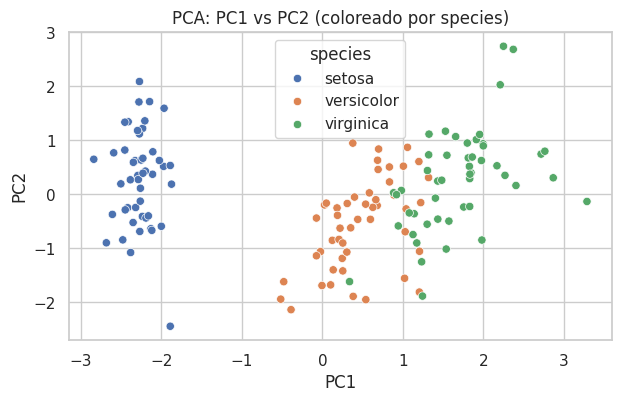


✅ Fin del EDA (Iris).


In [12]:
# 11) PCA sobre variables numéricas (sin 'species')
print("\n🧭 PCA sobre variables numéricas (Z-score)")
scaler2 = StandardScaler()
num_scaled = scaler2.fit_transform(Xy_clean[feature_cols])
pca = PCA()
pca_result = pca.fit_transform(num_scaled)

# Varianza explicada
print("Varianza explicada por cada componente principal:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")
print(f"Varianza acumulada (PC1..PC2): {(pca.explained_variance_ratio_[:2].sum()):.4f}")

# Scatter PC1 vs PC2 coloreado por especie
pca_df = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(pca_result.shape[1])])
pca_df['species'] = Xy_clean['species'].values

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='species')
plt.title("PCA: PC1 vs PC2 (coloreado por species)")
plt.show()

print("\n✅ Fin del EDA (Iris).")